In [ ]:
#HW3.1. Phase Systems
#查表

In [ ]:
#HW3.2. Closed, rigid tank
import numpy as np
T_initial = -20.0000 # °C
x_initial = 0.5036 # 
P_final = 6.0000 # bar
vf = 0.7427*10**(-3) # m^3/kg
vg = 0.0926 # m^3/kg
v1 = x_initial*vg + (1-x_initial)*vf

print("v1 =", v1, "m^3/kg")
v2=v1 
p_final=P_final*10**5 # Pa


#superheated vapor --->A9 
# t = 40 , v= 0.0463
# t = 50 , v= 0.0486
t = 40 + (50 - 40) * (0.047002036 - 0.0463) / (0.0486 - 0.0463)
print("t =", t, "°C")  

v1 = 0.047002036280000006 m^3/kg
t = 43.0523304347826 °C


In [2]:
pip install CoolProp

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#HW3.2. Closed, rigid tank
from CoolProp.CoolProp import PropsSI

def solve_rigid_tank_problem():
    # --- 1. 定义已知条件 ---
    fluid = 'R22'              # 制冷剂类型
    
    # 初始状态 (State 1)
    T1_C = -20.0000            # 初始温度 (摄氏度)
    x1 = 0.5036                # 初始干度 (Quality)
    
    # 最终状态 (State 2)
    P2_bar = 6.0000            # 最终压力 (bar)

    # --- 2. 单位换算 ---
    # CoolProp 使用国际单位制 (SI): 温度用开尔文(K), 压力用帕斯卡(Pa)
    T1_K = T1_C + 273.15
    P2_Pa = P2_bar * 1e5       # 1 bar = 100,000 Pa

    # --- 3. 计算过程 ---
    
    # 步骤 A: 计算初始状态的密度 (Density)
    # 输入: 温度(T), 干度(Q) -> 输出: 密度(D)
    # 注意：刚性容器意味着比体积 v 不变，因此密度 rho (1/v) 也不变
    rho1 = PropsSI('D', 'T', T1_K, 'Q', x1, fluid)
    
    # 步骤 B: 确定最终状态的密度
    rho2 = rho1  # 刚性容器，密度守恒
    
    # 步骤 C: 计算最终温度
    # 输入: 压力(P), 密度(D) -> 输出: 温度(T)
    T2_K = PropsSI('T', 'P', P2_Pa, 'D', rho2, fluid)
    
    # --- 4. 结果输出 ---
    T2_C = T2_K - 273.15
    
    print(f"Initial Density: {rho1:.4f} kg/m^3")
    print(f"Final Pressure: {P2_bar} bar")
    print(f"Final Temperature: {T2_C:.4f} °C")
    
    return T2_C

if __name__ == "__main__":
    solve_rigid_tank_problem()

Initial Density: 21.2573 kg/m^3
Final Pressure: 6.0 bar
Final Temperature: 43.8424 °C


In [ ]:
#HW3.3. Constant Pressure Process
import numpy as np

# 已知条件
P_initial = 200.00  # 初始压力，单位：lbf/in² (psia)
x_initial = 0.80     # 初始干度
T_final = 480.00    # 最终温度，单位：°F

# ----------------------
# 1. 查表数据（手动输入蒸汽表值）
# ----------------------
# 初始状态：200 psia 饱和水/蒸汽比容
vf = 0.01838  # ft³/lb，饱和水比容
vg = 2.288    # ft³/lb，饱和蒸汽比容

# 终态：200 psia 过热蒸汽比容（查表后插值）
v_450 = 2.538  # ft³/lb，450°F 比容
v_500 = 2.715  # ft³/lb，500°F 比容

# ----------------------
# 2. 计算初始比容 v1
# ----------------------
v1 = vf + x_initial * (vg - vf)

# ----------------------
# 3. 插值计算终态比容 v2
# ----------------------
delta_T = T_final - 450
v2 = v_450 + (delta_T / (500 - 450)) * (v_500 - v_450)

# ----------------------
# 4. 计算功 w（单位转换）
# ----------------------
# 压力转换：psi → lbf/ft²
P_lbf_ft2 = P_initial * 144
# 功的单位：lbf·ft/lb → Btu/lb
w_lbf_ft_lb = P_lbf_ft2 * (v2 - v1)
w_Btu_lb = w_lbf_ft_lb / 778.169

# 输出结果
print(f"初始比容 v1: {v1:.4f} ft³/lb")
print(f"终态比容 v2: {v2:.4f} ft³/lb")
print(f"过程功 w: {w_Btu_lb:.2f} Btu/lb")


p = 13.78951458 bar


In [8]:
#HW3.3. Constant Pressure Process
from CoolProp.CoolProp import PropsSI

def solve_constant_pressure_process():
    """
    活塞-气缸定压过程功计算
    """
    
    # ========== 1. 定义已知条件 ==========
    fluid = 'Water'              # 工质：水
    
    # 初始状态
    P_psi = 200.00               # 压力 (lbf/in² = psi)
    x1 = 0.80                    # 初始干度
    
    # 最终状态
    T2_F = 480.00                # 最终温度 (°F)
    
    # ========== 2. 单位转换 ==========
    # 压力：psi → Pa
    P_Pa = P_psi * 6894.76       # 1 psi = 6894.76 Pa
    
    # 温度：°F → K
    T2_K = (T2_F - 32) * 5/9 + 273.15
    
    # ========== 3. 计算初始状态比体积 ==========
    # 已知 P 和 x，求比体积 v
    # CoolProp 输出密度 D (kg/m³)，比体积 v = 1/D
    rho1 = PropsSI('D', 'P', P_Pa, 'Q', x1, fluid)
    v1_m3_kg = 1 / rho1          # m³/kg
    
    # ========== 4. 计算最终状态比体积 ==========
    # 定压过程：P2 = P1
    # 已知 P 和 T，求比体积 v
    rho2 = PropsSI('D', 'P', P_Pa, 'T', T2_K, fluid)
    v2_m3_kg = 1 / rho2          # m³/kg
    
    # ========== 5. 计算边界功 ==========
    # 定压过程功公式：w = P × (v₂ - v₁)
    # 单位：Pa × m³/kg = J/kg
    w_J_kg = P_Pa * (v2_m3_kg - v1_m3_kg)
    
    # ========== 6. 单位转换：J/kg → Btu/lb ==========
    # 1 Btu = 1055.06 J
    # 1 lb = 0.453592 kg
    # 所以：1 J/kg = 1/1055.06 Btu / (1/0.453592 lb) = 0.453592/1055.06 Btu/lb
    w_Btu_lb = w_J_kg * (0.453592 / 1055.06)
    
    # ========== 7. 输出结果 ==========
    print("=" * 60)
    print("定压过程功计算结果")
    print("=" * 60)
    print(f"压力 P = {P_psi} psi = {P_Pa/1000:.2f} kPa")
    print(f"初始干度 x₁ = {x1}")
    print(f"最终温度 T₂ = {T2_F}°F = {T2_K-273.15:.2f}°C")
    print("-" * 60)
    print(f"初始比体积 v₁ = {v1_m3_kg*16.0185:.4f} ft³/lb")
    print(f"最终比体积 v₂ = {v2_m3_kg*16.0185:.4f} ft³/lb")
    print("-" * 60)
    print(f"单位质量功 w = {w_Btu_lb:.4f} Btu/lb")
    print("=" * 60)
    
    return w_Btu_lb

# ========== 运行计算 ==========
if __name__ == "__main__":
    w = solve_constant_pressure_process()
    print(f"\n最终答案: w = {w:.4f} Btu/lb")

def solve_constant_pressure_process():
    """
    活塞-气缸定压过程功计算
    """
    
    # ========== 1. 定义已知条件 ==========
    fluid = 'Water'              # 工质：水
    
    # 初始状态
    P_psi = 200.00               # 压力 (lbf/in² = psi)
    x1 = 0.80                    # 初始干度
    
    # 最终状态
    T2_F = 480.00                # 最终温度 (°F)
    
    # ========== 2. 单位转换 ==========
    # 压力：psi → Pa
    P_Pa = P_psi * 6894.76       # 1 psi = 6894.76 Pa
    
    # 温度：°F → K
    T2_K = (T2_F - 32) * 5/9 + 273.15
    
    # ========== 3. 计算初始状态比体积 ==========
    # 已知 P 和 x，求比体积 v
    # CoolProp 输出密度 D (kg/m³)，比体积 v = 1/D
    rho1 = PropsSI('D', 'P', P_Pa, 'Q', x1, fluid)
    v1_m3_kg = 1 / rho1          # m³/kg
    
    # ========== 4. 计算最终状态比体积 ==========
    # 定压过程：P2 = P1
    # 已知 P 和 T，求比体积 v
    rho2 = PropsSI('D', 'P', P_Pa, 'T', T2_K, fluid)
    v2_m3_kg = 1 / rho2          # m³/kg
    
    # ========== 5. 计算边界功 ==========
    # 定压过程功公式：w = P × (v₂ - v₁)
    # 单位：Pa × m³/kg = J/kg
    w_J_kg = P_Pa * (v2_m3_kg - v1_m3_kg)
    
    # ========== 6. 单位转换：J/kg → Btu/lb ==========
    # 1 Btu = 1055.06 J
    # 1 lb = 0.453592 kg
    # 所以：1 J/kg = 1/1055.06 Btu / (1/0.453592 lb) = 0.453592/1055.06 Btu/lb
    w_Btu_lb = w_J_kg * (0.453592 / 1055.06)
    
    # ========== 7. 输出结果 ==========
    print("=" * 60)
    print("定压过程功计算结果")
    print("=" * 60)
    print(f"压力 P = {P_psi} psi = {P_Pa/1000:.2f} kPa")
    print(f"初始干度 x₁ = {x1}")
    print(f"最终温度 T₂ = {T2_F}°F = {T2_K-273.15:.2f}°C")
    print("-" * 60)
    print(f"初始比体积 v₁ = {v1_m3_kg*16.0185:.4f} ft³/lb")
    print(f"最终比体积 v₂ = {v2_m3_kg*16.0185:.4f} ft³/lb")
    print("-" * 60)
    print(f"单位质量功 w = {w_Btu_lb:.4f} Btu/lb")
    print("=" * 60)
    
    return w_Btu_lb

# ========== 运行计算 ==========
if __name__ == "__main__":
    w = solve_constant_pressure_process()
    print(f"\n最终答案: w = {w:.4f} Btu/lb")

定压过程功计算结果
压力 P = 200.0 psi = 1378.95 kPa
初始干度 x₁ = 0.8
最终温度 T₂ = 480.0°F = 248.89°C
------------------------------------------------------------
初始比体积 v₁ = 1.8342 ft³/lb
最终比体积 v₂ = 2.6553 ft³/lb
------------------------------------------------------------
单位质量功 w = 30.3890 Btu/lb

最终答案: w = 30.3890 Btu/lb
定压过程功计算结果
压力 P = 200.0 psi = 1378.95 kPa
初始干度 x₁ = 0.8
最终温度 T₂ = 480.0°F = 248.89°C
------------------------------------------------------------
初始比体积 v₁ = 1.8342 ft³/lb
最终比体积 v₂ = 2.6553 ft³/lb
------------------------------------------------------------
单位质量功 w = 30.3890 Btu/lb

最终答案: w = 30.3890 Btu/lb


In [ ]:
#HW3.4. Property Data
#判定为superheated vapor --->A4 表
#2
v=0.9
vf=0.0010528
vg=1.159
x=(v-vf)/(vg-vf)
print("x =", x)
uf=466.94
ug=2519.7
u=x*ug+(1-x)*uf
print("u =", u, "kJ/kg")


#0.267

x = 0.7763283161788379
u = 2060.555714319271 kJ/kg


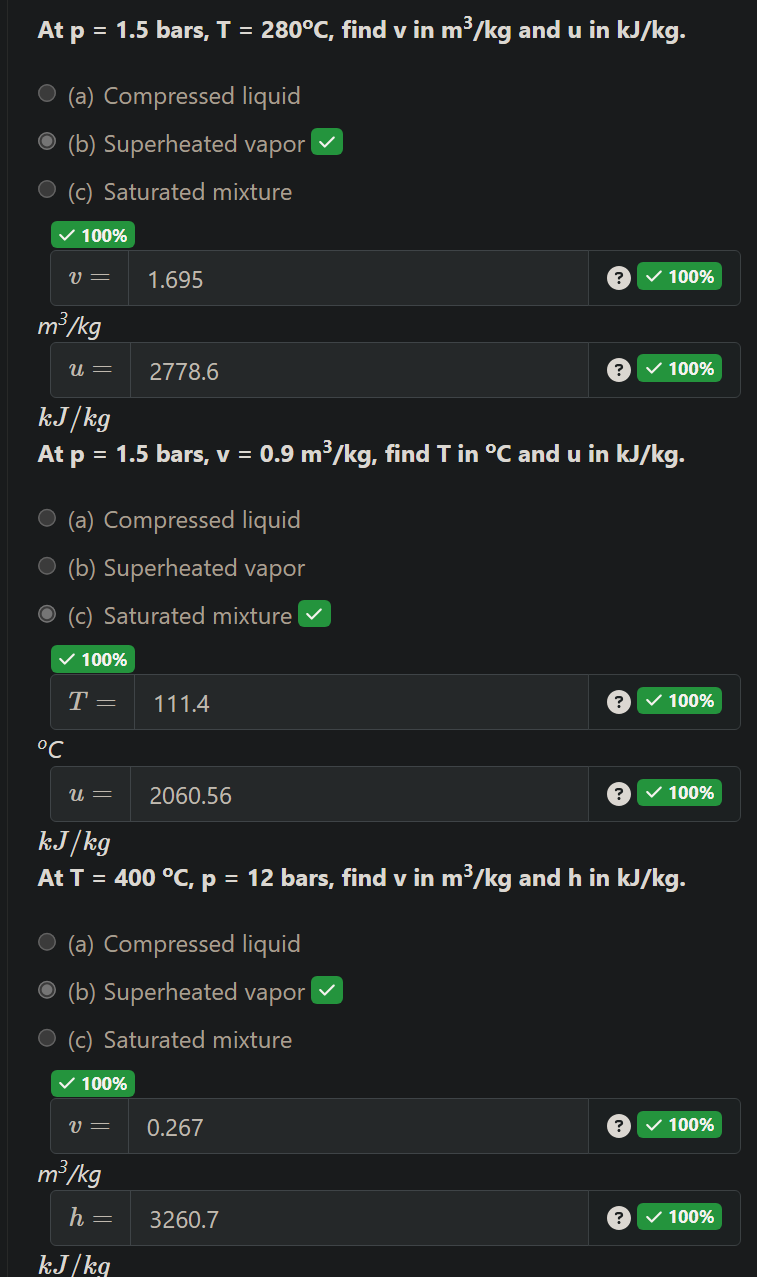

In [19]:
#HW3.5. Propane
from CoolProp.CoolProp import PropsSI

# 已知参数
p_psi = 200.0  # 定压，psi
T1_F = 200.0   # 初始温度，°F
W_Btu = -88.84 # 过程总功，Btu
m_lb = 7.0     # 丙烷质量，lb
fluid = "Propane"

# 单位转换
p_Pa = p_psi * 6894.75729  # psi转Pa
T1_K = (T1_F - 32) * 5/9 + 273.15  # °F转K
w_Btulb = W_Btu / m_lb  # 单位质量功，Btu/lb

# 1. 计算初始比体积v1（ft³/lb）
rho1 = PropsSI("Dmass", "P", p_Pa, "T", T1_K, fluid)
v1_ft3lb = (1 / rho1) * 16.018463  # m³/kg转ft³/lb

# 2. 计算最终比体积v2（ft³/lb）
v2_ft3lb = v1_ft3lb + (w_Btulb * 778.169) / (p_psi * 144)
print(f"初始比体积 v1 = {v1_ft3lb:.4f} ft³/lb")
print(f"最终比体积 v2 = {v2_ft3lb:.4f} ft³/lb")
# 3. 计算200 psi下的饱和比体积vf、vg
rho_f = PropsSI("Dmass", "P", p_Pa, "Q", 0, fluid)
rho_g = PropsSI("Dmass", "P", p_Pa, "Q", 1, fluid)
vf_ft3lb = (1 / rho_f) * 16.018463
vg_ft3lb = (1 / rho_g) * 16.018463

# 4. 相态判断与结果计算
if vf_ft3lb < v2_ft3lb < vg_ft3lb:
    x = (v2_ft3lb - vf_ft3lb) / (vg_ft3lb - vf_ft3lb)
    print(f"最终状态：饱和混合物，干度x = {x:.3f}")
elif v2_ft3lb > vg_ft3lb:
    rho2 = 1 / (v2_ft3lb / 16.018463)
    T2_K = PropsSI("T", "P", p_Pa, "Dmass", rho2, fluid)
    T2_F = (T2_K - 273.15) * 9/5 + 32
    print(f"最终状态：过热蒸汽，温度T2 = {T2_F:.2f} °F")
else:
    print("最终状态：压缩液体")


初始比体积 v1 = 0.7031 ft³/lb
最终比体积 v2 = 0.3602 ft³/lb
最终状态：饱和混合物，干度x = 0.661


In [20]:
#HW3.5. Propane
import numpy as np

p_1 = 200.0000 # lbf/in^2
T_1 = 200.0000 # F
W = -88.8400 # Btu 负号表示外界对系统做功
m = 7.0000 # lb
p=p_1*6894.75729 # Pa
T_1_K = (T_1 - 32) * 5/9 + 273.15 # K
w_Btulb = W / m # Btu/lb

print(T_1_K-273.15, "°C")
print(p/100000, "bar")
#查表发现初始状态为过热蒸汽

#要找在最终状态下的比体积v2
v1=0.7025 # ft^3/lb 初始状态的比体积,查表得
#W = m * P * (v2 - v1)  => v2 = v1 + W/(m*P)
v2 = v1 + (W * 778.169) / (m * p_1 * 144) # ft^3/lb
print("v2 =", v2, "ft^3/lb")

# 额外：判断终态状态（查丙烷饱和性质表）
v_f = 0.03432  # ft³/lb（200 lbf/in²下饱和液体比体积）
v_g = 0.5261   # ft³/lb（200 lbf/in²下饱和蒸汽比体积）
if v2 > v_g:
    print("终态为：过热蒸汽")
elif v2 < v_f:
    print("终态为：过冷液体")
else:
    # 计算干度x
    x = (v2 - v_f) / (v_g - v_f)
    print(f"终态为：气液饱和混合物，干度 x = {x:.4f}")

93.33333333333331 °C
13.789514579999999 bar
v2 = 0.3595806847222222 ft^3/lb
终态为：气液饱和混合物，干度 x = 0.6614


In [ ]:
#HW3.6. Rigid Tank
# 思路 
# 第一个状态p1 t1已知，算pr，tr 读图得到z1，用z=p*v/R*T得到v1
# 第二个状态p2 v2（=v1）已知 用vr=v*pc/tc/R 算pr vr读图得到z2，用z=p*v/R*T得到t2

from sympy import *

m = 0.3 # kg
P1 = 40.0 # bars
T1 = 180.0 # K
P2 = 33.0 # bars
#########################


P1=P1*1e5
P2=P2*1e5

#每种气体的Pc、Tc是固定值
R=8314/32
pc=50.5*1e5
tc=154 

pr=P1/pc
tr=T1/tc

# print(pr,tr)
# 读图 
Z1=0.83

v1=Z1*R*T1/P1
V1=v1*m
print(V1)


vr=v1*pc/tc/R
pr2=P2/pc
# print(vr,pr2)
# 读图
Z2=0.77
t2=P2*v1/R/Z2
print(t2)



0.0029111990625
160.07142857142858


In [22]:
#HW3.7. Quality of the mixture
import numpy as np
L1 = 32 # cm
L2 = 18 # cm
T = 150 # degree centigrade
vg=0.3928
vf=0.0010905
v=(L1+L2)/(L1/vg+L2/vf)
x=(v-vf)/(vg-vf)
print("x =", x*100, "%")



x = 0.49112661879251757 %
